# Анализ активности пользователей сервиса "Яндекс Книги" из Москвы и Санкт-Петербурга

- Автор: Гусев Александр Олегович

## Цели и задачи проекта

Проверить гипотезу о том, что осенью 2024 года пользователи из Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг в приложении "Яндекс Книги", чем пользователи из Москвы.

Задачи исследования:

- Подготовить и предобработать данные о пользователях из Москвы и Санкт-Петербурга.
- Выполнить проверку гипотезы с использованием статистических методов.
- Интерпретировать полученные результаты и сформулировать выводы.

## Описание данных

В проекте используются данные пользователей Яндекс Книг из Москвы и Санкт-Петербурга за период с 1 сентября по 11 декабря 2024 года.

Данные содержат следующие поля:

- `city` — город пользователя (Москва или Санкт-Петербург).
- `puid` — идентификатор пользователя.
- `hours` — общее количество часов активности пользователя за указанный период.

Эти данные были предварительно агрегированы в SQL для последующего статистического анализа.

## Содержимое проекта

1. Цели и задачи проекта
- Описание проекта
- Цель исследования, основные гипотезы

2. Описание данных

3. Загрузка данных и знакомство с ними
- Источник данных
- Первичный анализ (проверка наличия пропусков и аномалий)

4. Проверка гипотезы в Python
- Формулировка нулевой и альтернативной гипотез
- Выбор метода статистического тестирования
- Расчёт p-value и интерпретация результата

5. Аналитическая записка
- Выбранный статистический тест и уровень значимости
- Результат теста и его интерпретация
- Возможные объяснения полученных результатов
- Выводы и рекомендации

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df_knigi = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')
df_knigi.head()

# Проверяем общую информацию о данных
df_knigi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


**Вывод по загруженным данным:**

_Структура данных:_

Всего 8784 записи и 4 столбца: `Unnamed: 0`, `city`, `puid`, `hours`.
Unnamed: 0 — это лишний индекс из CSV, его можно удалить.

_Типы данных:_

- `city` (object) — название города (Москва или Санкт-Петербург).
- `puid` (int64) — идентификатор пользователя.
- `hours` (float64) — общее количество часов активности.

In [2]:
# Удаляем ненужный столбец
df_knigi.drop(columns=['Unnamed: 0'], inplace=True)

# Проверяем, что столбец удалён
df_knigi.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [3]:
# Проверяем наличие полных дубликатов
full_duplicates = df_knigi.duplicated().sum()

# Проверяем наличие дубликатов по puid
puid_duplicates = df_knigi.duplicated(subset=["puid"]).sum()

# Описательная статистика для анализа разброса значений
desc_stats = df_knigi["hours"].describe()

# Выводим результаты
display(full_duplicates, puid_duplicates, desc_stats)

0

244

count    8784.000000
mean       11.087670
std        37.701350
min         0.000018
25%         0.066246
50%         0.942344
75%         6.065151
max       978.764775
Name: hours, dtype: float64

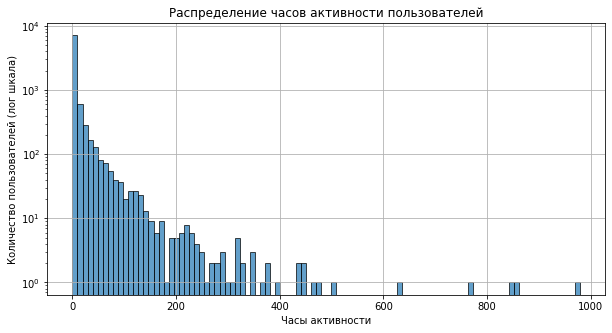

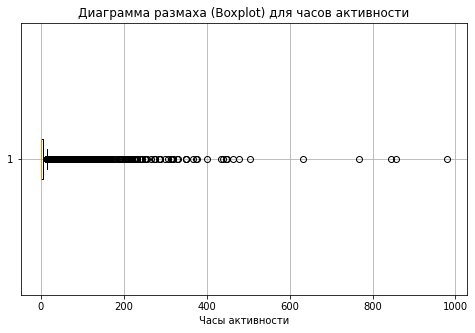

In [4]:
# Построим гистограмму распределения часов
plt.figure(figsize=(10, 5))
plt.hist(df_knigi["hours"], bins=100, edgecolor="black", alpha=0.7)
plt.yscale("log")  # Логарифмическая шкала, чтобы лучше видеть распределение
plt.xlabel("Часы активности")
plt.ylabel("Количество пользователей (лог шкала)")
plt.title("Распределение часов активности пользователей")
plt.grid(True)
plt.show()

# Построим boxplot для наглядности выбросов
plt.figure(figsize=(8, 5))
plt.boxplot(df_knigi["hours"], vert=False)
plt.xlabel("Часы активности")
plt.title("Диаграмма размаха (Boxplot) для часов активности")
plt.grid(True)
plt.show()

In [5]:
# Удаляем дубликаты по puid
df_knigi = df_knigi.drop_duplicates(subset=["puid"])

# Проверяем наличие дубликатов по puid
puid_duplicates = df_knigi.duplicated(subset=["puid"]).sum()

puid_duplicates

0

**Результаты проверки данных:**

- Удален лишний столбец `Unnamed: 0`, который был индексом.
- Полные дубликаты в данных отсутствуют.
- Дубликаты по `puid`: обнаружено 244 записи с одинаковыми `puid`, их удалим.

_Разброс значений `hours`:_
- Среднее значение: 11.09 часов.
- Минимальное значение: 0.000018 часов.
- 25-й перцентиль: 0.066 часов (много пользователей читают совсем мало).
- Медиана (50-й перцентиль): 0.94 часов.
- 75-й перцентиль: 6.07 часов.
- Максимальное значение: 978.76 часов (очень большой выброс).

_Решение по выбросам:_
- Чтобы сохранить наибольшее количество значений для теста, ограничим выбросы 99-м перцентилем.
- Очень низкие значения конечно тоже можно было бы ограничить, однако такие значения меньше похожи на ошибочные данные - пользователи действительно могли заходить на небольшой промежуток времени.

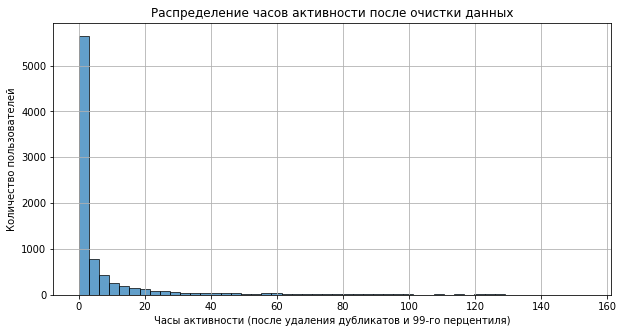

153.83918345454563

In [6]:
# Определяем 99-й перцентиль
percentile_99 = df_knigi["hours"].quantile(0.99)

# Ограничим данные 99 перцентилем
df_99 = df_knigi[df_knigi["hours"] <= percentile_99]

# Строим гистограмму после удаления дубликатов и ограничений 99-го перцентиля
plt.figure(figsize=(10, 5))
plt.hist(df_99["hours"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Часы активности (после удаления дубликатов и 99-го перцентиля)")
plt.ylabel("Количество пользователей")
plt.title("Распределение часов активности после очистки данных")
plt.grid(True)
plt.show()

percentile_99

**Результаты**

Что видно на графике:
- Основная масса пользователей все еще вначале графика - с минимальными значениями обработку мы не проводили.
- Длинный "хвост" активных пользователей стал короче – удалены экстремальные значения свыше 153.8 часов.
- Распределение осталось сильно скошенным – много пользователей с минимальным временем и плавный спад к более активным, однако так мы имеем более реальную картину среднего времени активности, при этом сохранив наибольшее количество исходных данных.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в Санкт-Петербурге не выше, чем средняя активность пользователей в Москве

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге выше, чем средняя активность пользователей в Москве

Необходимо:
- разделить пользователей на две группы: Москва и Санкт-Петербург.
- провести односторонний t-тест (сравнить средние значения часов активности).
- вычислить p-value и интерпретировать результат.

In [7]:
# Разделяем данные на две группы
moscow_hours = df_99[df_99['city'] == 'Москва']['hours']
spb_hours = df_99[df_99['city'] == 'Санкт-Петербург']['hours']

# Выполняем односторонний t-тест
t_stat, p_value = stats.ttest_ind(spb_hours, moscow_hours, alternative='greater')

# Выводим результаты
print(f"T-статистика: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

# Проверяем значимость результата
alpha = 0.05  # уровень значимости 5%
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: пользователи из СПб действительно проводят больше времени.")
else:
    print("Не удалось отвергнуть нулевую гипотезу: статистически значимого отличия нет.")

T-статистика: 0.609
P-value: 0.27129
Не удалось отвергнуть нулевую гипотезу: статистически значимого отличия нет.


**Вывод:**
- Так как p-value (0.271) > 0.05, мы не можем отвергнуть нулевую гипотезу.
- Мы не получили статистически значимого подтверждения того, что среднее время активности в СПб выше.
- Однако, это не доказывает, что они равны или что Москва активнее, мы просто не смогли доказать, что активность выше в СПб.

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



**Выбранный тип теста и уровень статистической значимости**

- Для проверки гипотезы использовался t-тест для независимых выборок (тест Стьюдента).
- Так как мы проверяли, проводят ли пользователи из Санкт-Петербурга больше времени за чтением и прослушиванием книг, тест был односторонним (alternative='greater').

_Выбранный уровень статистической значимости (alpha)_: 0.05 (5%).

**Результат теста (p-value)**

- T-статистика: 0.609 (насколько Москва и Санкт-Петербург различаются по среднему значению. В данном случае - незначительно)
- P-value: 0.271

**Выводы**

- Так как p-value (0.271) > 0.05, у нас нет достаточных оснований отвергнуть нулевую гипотезу.
- Это означает, что мы не можем статистически доказать, что пользователи из Санкт-Петербурга проводят больше времени в приложении, чем пользователи из Москвы.

**Возможные причины такого результата**

_Схожее поведение пользователей_

- Москва и Санкт-Петербург — оба крупных мегаполиса с похожими социально-экономическими условиями, что может объяснять отсутствие значительной разницы в потреблении контента.

_Недостаточная выборка или разброс данных_

- Возможно, пользователи из Санкт-Петербурга действительно читают больше, но выборка не позволяет статистически подтвердить это различие.
- Также мы все еще имеем высокую дисперсию (разброс) данных, из-за чего разница сглаживается.

**Заключение**

Исходя из полученных данных, гипотеза о том, что пользователи из Санкт-Петербурга проводят больше времени за чтением, не получила статистического подтверждения. Для более точного анализа можно было бы рассмотреть другие параметры (например, частоту сессий, жанры контента) или увеличить выборку.